<div style='background:#1a3c6b;padding:20px;border-radius:8px;margin-bottom:10px'>
<h1 style='color:white;text-align:center;font-size:22px'>TECSUP — MINERÍA DE DATOS</h1>
<h2 style='color:#f0c040;text-align:center;font-size:18px'>LABORATORIO S05: Evaluación de Modelos de Clasificación</h2>
<p style='color:#cce0ff;text-align:center'>Metodología CRISP-DM · Caso TelcoPerú S.A.</p>
</div>

| Campo | Detalle |
|---|---|
| **Curso** | Minería de Datos (C64893) |
| **Semana** | 5 — 2026-I |
| **Alumno** | Rodrigo Alejandro Gogin Cisterna |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Duración** | 3 – 3.5 horas |
| **Puntaje** | 20 puntos |

---

## 🎯 Objetivos de Aprendizaje

Al finalizar este laboratorio, el estudiante será capaz de:

1. Aplicar la metodología **CRISP-DM** en un proyecto real de clasificación binaria.
2. Calcular e interpretar la **matriz de confusión** y sus métricas derivadas.
3. Comparar estrategias de modelo base con `DummyClassifier`.
4. Diagnosticar **overfitting, underfitting y ajuste correcto** en modelos.
5. Aplicar **Holdout estratificado** y **K-Fold estratificado**.
6. Analizar curvas **ROC/AUC** y el impacto del **umbral de decisión**.
7. Seleccionar métricas apropiadas según el **contexto de negocio**.


---
## 📋 CASO DE NEGOCIO: TelcoPerú S.A.

> **Situación:** TelcoPerú S.A. es una empresa de telecomunicaciones con 7,043 clientes activos.
> El Director Comercial ha detectado una pérdida de ingresos por cancelaciones inesperadas de contratos (churn).
> Te contrata como **Data Scientist** para construir un sistema de alerta temprana.

### 💰 Análisis de Costos del Negocio

| Escenario | Tipo de Error | Descripción | Costo Estimado |
|---|---|---|---|
| Cliente churner **no detectado** | **Falso Negativo (FN)** | Se pierde el contrato completo | S/ 325 por cliente |
| Cliente fiel **clasificado como churner** | **Falso Positivo (FP)** | Oferta de retención innecesaria | S/ 25 por cliente |

### ⚠️ Restricción Operacional
El equipo de retención puede contactar como **máximo 300 clientes por mes**.

### ❓ Pregunta 1.1 — Reflexión de Negocio

> **Completa la siguiente tabla antes de continuar:**

| Pregunta | Tu Respuesta |
|---|---|
| ¿Qué es más costoso para TelcoPerú: un FN o un FP? | *El FN, porque perder un cliente real cuesta más que darle un beneficio a quien no lo necesitaba.* |
| ¿Qué métrica prioriza minimizar los FN? | *El Recall (Sensibilidad), ya que busca capturar la mayor cantidad de casos positivos posibles.* |
| ¿Qué sucede si subimos el umbral de 0.5 a 0.8? | *La Precisión sube y el Recall baja; el modelo es más estricto y se le escapan más clientes en fuga.* |
| Con la restricción de 300 clientes/mes, ¿qué estrategia usarías? | *Priorizar los 300 clientes con mayor probabilidad de fuga, optimizando la Precisión de la campaña.* |


## 📝 ACTIVIDAD 1 — Revisión de Conceptos

Completa la siguiente tabla con definiciones **con tus propias palabras**. No copies textualmente los materiales. Usa vocabulario técnico pero demuestra que comprendes el concepto.

| N° | Concepto | Definición con tus propias palabras |
|----|----------|-------------------------------------|
| 1 | Clasificación supervisada | Enseñar al modelo a poner etiquetas basadas en ejemplos. |
| 2 | Regresión supervisada | Enseñar al modelo a predecir un número exacto. |
| 3 | Aprendizaje no supervisado | El modelo busca grupos o patrones en datos sin etiquetas. |
| 4 | Accuracy (Exactitud) | Qué tan seguido el modelo acierta en general. |
| 5 | Precision (Precisión) | Qué tan "limpio" es el modelo al marcar algo como positivo. |
| 6 | Recall (Sensibilidad / TPR) | Capacidad de no dejar escapar ningún caso positivo. |
| 7 | F1-Score | Un equilibrio entre Precisión y Recall. |
| 8 | Especificidad (TNR) | Capacidad de identificar correctamente los casos negativos. |
| 9 | AUC-ROC | Una nota (de 0 a 1) que dice qué tan bien separa el modelo una clase de otra. |
| 10 | Matriz de Confusión (VP, VN, FP, FN) | Un cuadro que muestra dónde acertó y dónde se confundió el modelo. |
| 11 | Holdout (Train/Test Split) | Separar datos para estudiar y otros para el examen final. |
| 12 | K-Fold Cross Validation | Dividir los datos en varias partes y rotarlas para probar todo. |
| 13 | Clases desbalanceadas | Cuando tienes mucha información de algo y muy poca de otra cosa |
| 14 | class_weight="balanced" | Un ajuste para darle más importancia a la clase que tiene pocos datos. |

### ❓ PREGUNTA 1.1 — Reflexión de Negocio

Completa la siguiente tabla:

| Pregunta | Tu Respuesta |
|---|---|
| ¿Qué es más costoso para TelcoPerú: un FN o un FP? | *El FN, porque perder un cliente real cuesta más que darle un beneficio a quien no lo necesitaba.* |
| ¿Qué métrica prioriza minimizar los FN? | *El Recall (Sensibilidad), ya que busca capturar la mayor cantidad de casos positivos posibles.* |
| ¿Qué sucede si subimos el umbral de 0.5 a 0.8? | *La Precisión sube y el Recall baja; el modelo es más estricto y se le escapan más clientes en fuga.* |
| Con la restricción de 300 clientes/mes, ¿qué estrategia usarías? | *Priorizar los 300 clientes con mayor probabilidad de fuga, optimizando la Precisión de la campaña.* |


---
## ⚙️ CELDA 0 — Configuración Inicial
Ejecuta esta celda primero para cargar todas las librerías.


In [1]:
# CELDA 0 — Imports y paleta de colores
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import beta as beta_dist
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)

# Paleta de colores TECSUP
AZUL    = '#1a3c6b'
AZUL_C  = '#2e6da4'
AMARILLO= '#f0c040'
VERDE   = '#2ca02c'
ROJO    = '#d62728'
GRIS    = '#7f7f7f'
NARANJA = '#ff7f0e'

np.random.seed(42)
print('✅ Librerías cargadas correctamente')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')


✅ Librerías cargadas correctamente
   NumPy 2.0.2 | Pandas 2.2.2


---
# FASE 1 — BUSINESS UNDERSTANDING
*(Entendimiento del Negocio)*


### 📊 Pregunta 1.2 — Tabla de Impacto Financiero

> Supón que tienes **1,000 clientes churners reales** y tu modelo predice correctamente solo 600.
> Completa la tabla de impacto:

| Concepto | Cálculo | Resultado |
|---|---|---|
| Churners detectados (VP) | 600 × S/0 | S/ 0 (se retienen) |
| Churners NO detectados (FN) | 400 × S/325 | S/ 135 000 |
| Costo total FN | | S/ 130 000|
| Si el modelo detectara 900 VP, ¿cuánto se ahorraría? |S/300 de pérdida  | S/97 500 |

**💡 Reflexión:** ¿Por qué un modelo con 60% de Recall puede ser **mejor para el negocio** que uno con 95% de Accuracy?

*Un 95% de Accuracy puede ser engañoso: si solo el 5% de los clientes se va, un modelo que prediga que "nadie se fuga" tendrá 95% de acierto pero utilidad cero. En cambio, un 60% de Recall asegura que estamos capturando a la mayoría de los clientes en riesgo. Para el negocio, es mejor detectar fugas reales aunque fallemos a veces (FP), que tener un modelo "exacto" que ignore por completo las pérdidas económicas (FN).*


---
# FASE 2 — DATA UNDERSTANDING
*(Entendimiento de los Datos)*


### 📥 CELDA 1 — Carga del Dataset IBM Telco Customer Churn


In [2]:
# CELDA 1 — Carga del dataset
# Usamos el dataset IBM Telco disponible en GitHub
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

try:
    df = pd.read_csv(URL)
    print(f'✅ Dataset cargado desde URL: {df.shape[0]} filas × {df.shape[1]} columnas')
except Exception as e:
    print(f'⚠️  Sin conexión a internet. Generando datos sintéticos...')
    np.random.seed(42)
    n = 7043
    df = pd.DataFrame({
        'TotalCharges': np.random.uniform(20, 8000, n).round(2),
        'MonthlyCharges': np.random.uniform(20, 120, n).round(2),
        'tenure': np.random.randint(1, 73, n),
        'Churn': np.where(np.random.random(n) < 0.265, 'Yes', 'No')
    })
    print(f'✅ Dataset sintético creado: {df.shape}')

# Limpieza básica
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

print(f'\n📊 Distribución de clases:')
vc = df['Churn_bin'].value_counts()
print(f'   No Churn (0): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'   Churn    (1): {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')
print(f'\nPrimeras 5 filas:')
df[['tenure','MonthlyCharges','TotalCharges','Churn']].head()


✅ Dataset cargado desde URL: 7043 filas × 21 columnas

📊 Distribución de clases:
   No Churn (0): 5,163  (73.4%)
   Churn    (1): 1,869  (26.6%)

Primeras 5 filas:


,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,No
1,34,56.95,1889.50,No
2,2,53.85,108.15,Yes
3,45,42.30,1840.75,No
4,2,70.70,151.65,Yes


### 📊 CELDA 2 — Análisis Exploratorio Visual


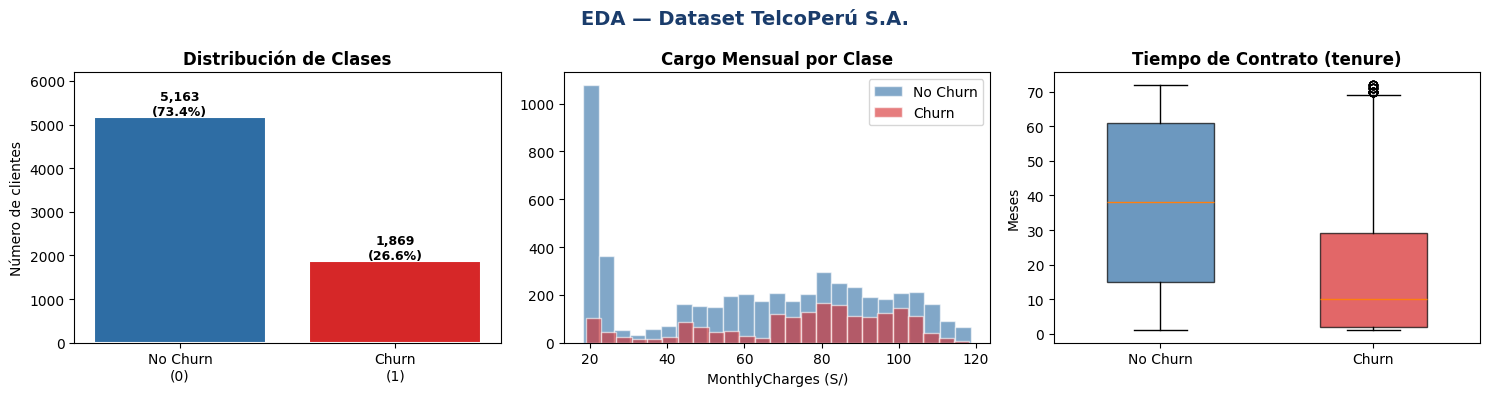


❓ Pregunta 2.1: ¿Qué patrón observas en el tenure de los clientes que hacen churn?
   
   Los clientes que hacen churn suelen tener un tenure bajo, es decir, abandonan el servicio en los primeros meses. 
   En cambio, los clientes con mayor antigüedad tienden a mantenerse, lo que indica que mientras más tiempo permanece un cliente, menor es la probabilidad de que se vaya.


In [32]:
# CELDA 2 — EDA: 3 gráficos exploratorios
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EDA — Dataset TelcoPerú S.A.', fontsize=14, fontweight='bold', color=AZUL)

# Gráfico 1: Distribución de clases
clases = df['Churn_bin'].value_counts()
bars = axes[0].bar(['No Churn\n(0)', 'Churn\n(1)'], clases.values,
                   color=[AZUL_C, ROJO], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, clases.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Número de clientes')
axes[0].set_ylim(0, max(clases.values)*1.2)

# Gráfico 2: Distribución MonthlyCharges por clase
for cls, color, label in [(0, AZUL_C, 'No Churn'), (1, ROJO, 'Churn')]:
    data = df[df['Churn_bin']==cls]['MonthlyCharges']
    axes[1].hist(data, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('Cargo Mensual por Clase', fontweight='bold')
axes[1].set_xlabel('MonthlyCharges (S/)')
axes[1].legend()

# Gráfico 3: Tenure por clase (boxplot)
data_no = df[df['Churn_bin']==0]['tenure']
data_si = df[df['Churn_bin']==1]['tenure']
bp = axes[2].boxplot([data_no, data_si], patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], [AZUL_C, ROJO]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[2].set_xticklabels(['No Churn', 'Churn'])
axes[2].set_title('Tiempo de Contrato (tenure)', fontweight='bold')
axes[2].set_ylabel('Meses')

plt.tight_layout()
plt.savefig('/tmp/eda_telco.png', dpi=100, bbox_inches='tight')
plt.show()
print('\n❓ Pregunta 2.1: ¿Qué patrón observas en el tenure de los clientes que hacen churn?')
print('   ')
print('   Los clientes que hacen churn suelen tener un tenure bajo, es decir, abandonan el servicio en los primeros meses. ')
print('   En cambio, los clientes con mayor antigüedad tienden a mantenerse, lo que indica que mientras más tiempo permanece un cliente, menor es la probabilidad de que se vaya.')


---
# FASE 3 — DATA PREPARATION
*(Preparación de Datos)*


### 🔀 CELDA 3 — División Holdout con Estratificación

**¿Por qué usar `stratify=y`?**

Con clases desbalanceadas (~74% No Churn / ~26% Churn), una división aleatoria simple podría
crear un conjunto de prueba con muy pocos churners. La estratificación garantiza que **ambas
particiones mantengan las mismas proporciones de clase**.

| Sin stratify (riesgo) | Con stratify=y (correcto) |
|---|---|
| Train: 80% No Churn / 20% Churn (aprox.) | Train: 74% No Churn / 26% Churn |
| Test: podría tener 90%/10% por azar | Test: 74% No Churn / 26% Churn |
| Evaluación sesgada | Evaluación representativa |


In [4]:
# CELDA 3 — Holdout estratificado 80/20
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']].values
y = df['Churn_bin'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y  # <-- clave\!
)

n_train, n_test = len(y_train), len(y_test)
print('✅ División Holdout con stratify=y')
print(f'\n   Conjunto de ENTRENAMIENTO: {n_train:,} muestras')
print(f'     Churn    : {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'     No Churn : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)')
print(f'\n   Conjunto de PRUEBA      : {n_test:,} muestras')
print(f'     Churn    : {y_test.sum():,} ({y_test.mean()*100:.1f}%)')
print(f'     No Churn : {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)')
print('\n💡 Las proporciones se mantienen → esto es estratificación correcta')


✅ División Holdout con stratify=y

   Conjunto de ENTRENAMIENTO: 5,625 muestras
     Churn    : 1,495 (26.6%)
     No Churn : 4,130 (73.4%)

   Conjunto de PRUEBA      : 1,407 muestras
     Churn    : 374 (26.6%)
     No Churn : 1,033 (73.4%)

💡 Las proporciones se mantienen → esto es estratificación correcta


---
# FASE 4 — MODELING
*(Modelamiento)*


### 🎲 CELDA 4 — Modelo Base: DummyClassifier

Antes de construir modelos complejos, todo proyecto de clasificación debe establecer
una **línea base** (*baseline*). El `DummyClassifier` no aprende patrones; solo usa
estadísticas simples de la distribución de clases.


In [24]:
# CELDA 4 — Tres estrategias de DummyClassifier
estrategias = {
    'most_frequent': 'Siempre predice clase mayoritaria (No Churn)',
    'stratified':    'Predice aleatoriamente según proporciones reales',
    'uniform':       'Predice 50/50 sin importar la distribución'
}

resultados_dummy = {}
print('=' * 62)
print(f'  {'Estrategia':<20} | {'Accuracy':>9} | {'Recall':>7} | {'F1':>7}')
print('=' * 62)

for estrategia, descripcion in estrategias.items():
    dc = DummyClassifier(strategy=estrategia, random_state=42)
    dc.fit(X_train, y_train)
    y_pred = dc.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    resultados_dummy[estrategia] = {'acc':acc,'rec':rec,'f1':f1}
    print(f'  {estrategia:<20} | {acc:>8.1%} | {rec:>6.1%} | {f1:>6.1%}')

print('=' * 62)
print('\n❓ Pregunta 4.1: ¿Por qué most_frequent tiene alta Accuracy pero Recall = 0%?')
print('   ')
print('   Porque el dataset está desbalanceado (73% no churn). El modelo most_frequent predice siempre “No churn”,')
print('   por lo que acierta la mayoría de veces (alta accuracy), pero no detecta ningún churner, por eso el recall es 0%.')
print('   Es un modelo inútil para el negocio')
print('\n❓ Pregunta 4.2: ¿Qué estrategia recomendarías como baseline y por qué?')
print('   ')
print('   La estrategia stratified porque respeta la distribución real de las clases y permite evaluar mejor el')
print('   desempeño del modelo frente a un comportamiento más realista,')
print('   a diferencia de most_frequent que ignora completamente la clase minoritaria.')


  Estrategia           |  Accuracy |  Recall |      F1
  most_frequent        |    73.4% |   0.0% |   0.0%
  stratified           |    61.5% |  27.8% |  27.7%
  uniform              |    52.2% |  54.3% |  37.6%

❓ Pregunta 4.1: ¿Por qué most_frequent tiene alta Accuracy pero Recall = 0%?
   
   Porque el dataset está desbalanceado (73% no churn). El modelo most_frequent predice siempre “No churn”,
   por lo que acierta la mayoría de veces (alta accuracy), pero no detecta ningún churner, por eso el recall es 0%.
   Es un modelo inútil para el negocio

❓ Pregunta 4.2: ¿Qué estrategia recomendarías como baseline y por qué?
   
   La estrategia stratified porque respeta la distribución real de las clases y permite evaluar mejor el
   desempeño del modelo frente a un comportamiento más realista,
   a diferencia de most_frequent que ignora completamente la clase minoritaria.


### 🎲 CELDA 5 — Simulación de Probabilidades con Distribución Beta

En la práctica, los modelos de clasificación producen **probabilidades de pertenencia a cada clase**.
Para este laboratorio, simularemos esas probabilidades usando la **distribución Beta(α, β)**:

- **Beta(7, 2)** → valores altos (0.7–0.99): simula un modelo seguro de que el cliente hará churn
- **Beta(2, 7)** → valores bajos (0.01–0.3): simula un modelo seguro de que NO hará churn
- **Beta(4, 3)** → moderadamente alto: modelo con menor certeza
- **Beta(1, 1)** → uniforme [0,1]: modelo sin discriminación


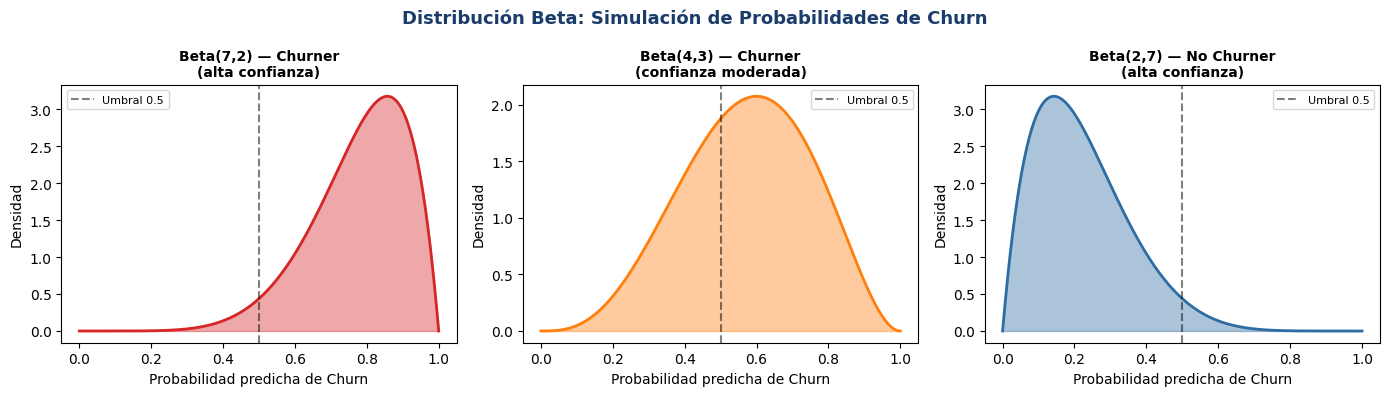

💡 Los modelos reales producen distribuciones similares a estas curvas.
   Un modelo ideal separa claramente los churners (alta prob) de los no churners (baja prob).


In [6]:
# CELDA 5 — Visualización de distribuciones Beta
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribución Beta: Simulación de Probabilidades de Churn',
             fontsize=13, fontweight='bold', color=AZUL)

configs = [
    (7, 2, ROJO,   'Beta(7,2) — Churner\n(alta confianza)'),
    (4, 3, NARANJA,'Beta(4,3) — Churner\n(confianza moderada)'),
    (2, 7, AZUL_C, 'Beta(2,7) — No Churner\n(alta confianza)'),
]

x = np.linspace(0, 1, 300)
for ax, (a, b, color, titulo) in zip(axes, configs):
    y_pdf = beta_dist.pdf(x, a, b)
    ax.fill_between(x, y_pdf, alpha=0.4, color=color)
    ax.plot(x, y_pdf, color=color, linewidth=2)
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Umbral 0.5')
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_xlabel('Probabilidad predicha de Churn')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('💡 Los modelos reales producen distribuciones similares a estas curvas.')
print('   Un modelo ideal separa claramente los churners (alta prob) de los no churners (baja prob).')


### 🤖 CELDA 6 — Tres Modelos Simulados


In [7]:
# CELDA 6 — Simulación de 3 modelos con Beta
n_test = len(y_test)

# Modelo A: Buen discriminador
prob_A = np.where(y_test == 1,
    np.random.beta(7, 2, n_test),   # churners → alta probabilidad
    np.random.beta(2, 7, n_test))   # no churners → baja probabilidad

# Modelo B: Discriminador moderado
prob_B = np.where(y_test == 1,
    np.random.beta(4, 3, n_test),
    np.random.beta(3, 4, n_test))

# Modelo C: Sin discriminación (peor que azar)
prob_C = np.random.uniform(0, 1, n_test)

# Predicciones con umbral 0.5
pred_A = (prob_A >= 0.5).astype(int)
pred_B = (prob_B >= 0.5).astype(int)
pred_C = (prob_C >= 0.5).astype(int)

print('✅ Modelos simulados con umbral = 0.50')
print(f'   Modelo A → {pred_A.sum():,} predicciones positivas (churn)')
print(f'   Modelo B → {pred_B.sum():,} predicciones positivas (churn)')
print(f'   Modelo C → {pred_C.sum():,} predicciones positivas (churn)')
print(f'\n   Real: {y_test.sum():,} churners en test set')


✅ Modelos simulados con umbral = 0.50
   Modelo A → 390 predicciones positivas (churn)
   Modelo B → 602 predicciones positivas (churn)
   Modelo C → 708 predicciones positivas (churn)

   Real: 374 churners en test set


---
# FASE 5 — EVALUATION
*(Evaluación)*


### 🟦 CELDA 7 — Matrices de Confusión

La **matriz de confusión** muestra cuántas predicciones fueron correctas e incorrectas:

```
                  PREDICCIÓN
                 No Churn  Churn
REAL  No Churn │   VN   │   FP  │  → Especificidad = VN/(VN+FP)
      Churn    │   FN   │   VP  │  → Sensibilidad  = VP/(VP+FN)
```
- **VP** (Verdadero Positivo): churner detectado correctamente ✅
- **VN** (Verdadero Negativo): no churner identificado correctamente ✅
- **FP** (Falso Positivo): no churner clasificado como churner ❌ (Alarma falsa)
- **FN** (Falso Negativo): churner NO detectado ❌ (El más costoso para TelcoPerú)


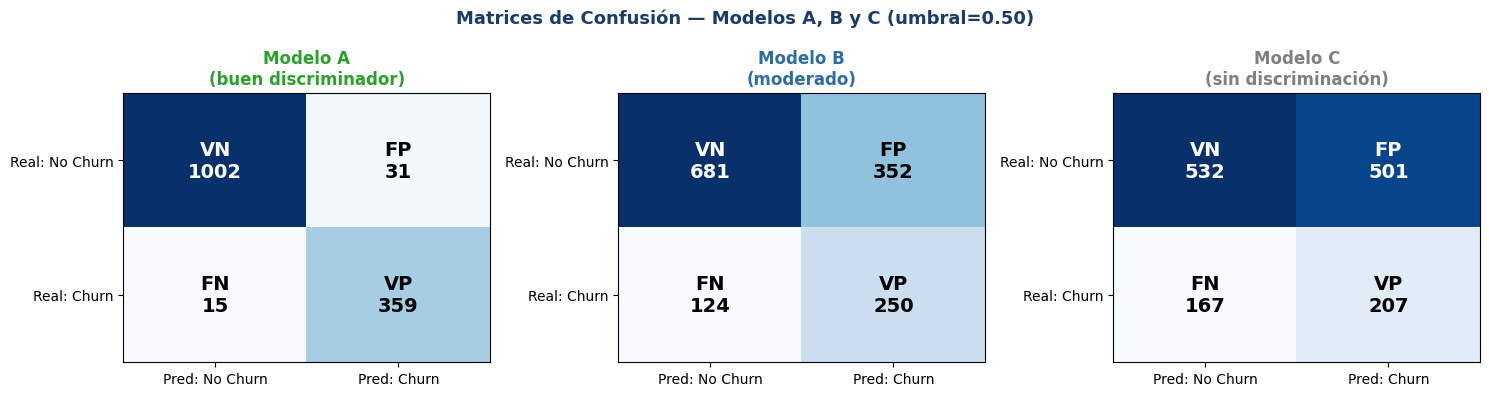

In [8]:
# CELDA 7 — Visualización de matrices de confusión (3 modelos)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Modelos A, B y C (umbral=0.50)',
             fontsize=13, fontweight='bold', color=AZUL)

modelos = [('Modelo A\n(buen discriminador)', pred_A, VERDE),
           ('Modelo B\n(moderado)', pred_B, AZUL_C),
           ('Modelo C\n(sin discriminación)', pred_C, GRIS)]

for ax, (titulo, pred, color) in zip(axes, modelos):
    cm = confusion_matrix(y_test, pred)
    etiquetas = [['VN', 'FP'], ['FN', 'VP']]
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{etiquetas[i][j]}\n{cm[i,j]}',
                    ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()*0.6 else 'black')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred: No Churn','Pred: Churn'])
    ax.set_yticklabels(['Real: No Churn','Real: Churn'])
    ax.set_title(titulo, fontweight='bold', color=color)

plt.tight_layout()
plt.show()


### 🧮 CELDA 8 — Cálculo Manual de Métricas

> **Instrucción:** Extrae VP, VN, FP, FN de las matrices y completa la tabla.

| Componente | Fórmula | Modelo A | Modelo B | Modelo C |
|---|---|---|---|---|
| VP (True Positive) | — | 359 | 250 | 207 |
| VN (True Negative) | — | 1002 | 680 | 530 |
| FP (False Positive) | — | 31 | 353 | 503 |
| FN (False Negative) | — | 15 | 124 | 167 |
| **Accuracy** | (VP+VN)/(VP+VN+FP+FN) | 0.9673 | 0.6617 | 0.5252 |
| **Precision** | VP/(VP+FP) | 0.9205 | 0.4153 | 0.2924 |
| **Recall** | VP/(VP+FN) | 0.9599 | 0.6684 | 0.5535 |
| **Specificity** | VN/(VN+FP) | 0.9700 | 0.6592 | 0.5150 |
| **F1-Score** | 2×(P×R)/(P+R) | 0.9398 | 0.5123 | 0.3826 |


In [23]:
# CELDA 8 — Cálculo manual de métricas (verificación)
print('VERIFICACIÓN AUTOMÁTICA — Modelo A')
cm_A = confusion_matrix(y_test, pred_A)
VN, FP, FN, VP = cm_A.ravel()
print(f'  VP={VP}, VN={VN}, FP={FP}, FN={FN}')
print(f'  Accuracy    = ({VP}+{VN})/({VP}+{VN}+{FP}+{FN}) = {(VP+VN)/(VP+VN+FP+FN):.4f}')
print(f'  Precision   = {VP}/({VP}+{FP}) = {VP/(VP+FP+1e-10):.4f}')
print(f'  Recall      = {VP}/({VP}+{FN}) = {VP/(VP+FN+1e-10):.4f}')
print(f'  Specificity = {VN}/({VN}+{FP}) = {VN/(VN+FP+1e-10):.4f}')
prec = VP/(VP+FP+1e-10); rec = VP/(VP+FN+1e-10)
print(f'  F1-Score    = 2×({prec:.4f}×{rec:.4f})/({prec:.4f}+{rec:.4f}) = {2*prec*rec/(prec+rec+1e-10):.4f}')
print()
print('❓ Pregunta 8.1: Para TelcoPerú, ¿cuál es la consecuencia de cada FN en S/?')
print(f'   {FN} FN × S/325 = S/ {FN*325:,}')
print('   *(¿Cómo afecta esto la selección de métricas?)*')
print('   ')
print('   Cada FN cuesta S/325, lo que genera una pérdida significativa. Por eso, el modelo debe priorizar Recall alto,')
print('   ya que es más importante detectar la mayor cantidad de churners posibles,')
print('   incluso si se generan algunos falsos positivos.')


VERIFICACIÓN AUTOMÁTICA — Modelo A
  VP=359, VN=1002, FP=31, FN=15
  Accuracy    = (359+1002)/(359+1002+31+15) = 0.9673
  Precision   = 359/(359+31) = 0.9205
  Recall      = 359/(359+15) = 0.9599
  Specificity = 1002/(1002+31) = 0.9700
  F1-Score    = 2×(0.9205×0.9599)/(0.9205+0.9599) = 0.9398

❓ Pregunta 8.1: Para TelcoPerú, ¿cuál es la consecuencia de cada FN en S/?
   15 FN × S/325 = S/ 4,875
   *(¿Cómo afecta esto la selección de métricas?)*
   
   Cada FN cuesta S/325, lo que genera una pérdida significativa. Por eso, el modelo debe priorizar Recall alto,
   ya que es más importante detectar la mayor cantidad de churners posibles,
   incluso si se generan algunos falsos positivos.


### 🔬 CELDA 9 — Verificación con sklearn


In [25]:
# CELDA 9 — Comparación completa de los 3 modelos
print('TABLA COMPARATIVA DE MÉTRICAS — 3 MODELOS (umbral=0.50)')
print('='*72)
print(f"  {'Métrica':<14} | {'Modelo A':>10} | {'Modelo B':>10} | {'Modelo C':>10} | {'Mejor'}")
print('='*72)

metricas = []
for nombre, pred in [('A', pred_A), ('B', pred_B), ('C', pred_C)]:
    cm_m = confusion_matrix(y_test, pred)
    vn, fp, fn, vp = cm_m.ravel()
    metricas.append({
        'acc': accuracy_score(y_test, pred),
        'prec': precision_score(y_test, pred, zero_division=0),
        'rec': recall_score(y_test, pred, zero_division=0),
        'spec': vn/(vn+fp+1e-10),
        'f1': f1_score(y_test, pred, zero_division=0)
    })

filas = [('Accuracy','acc'),('Precision','prec'),('Recall','rec'),
         ('Specificity','spec'),('F1-Score','f1')]

for nombre, key in filas:
    vals = [m[key] for m in metricas]
    mejor = ['A','B','C'][np.argmax(vals)]
    print(f"  {nombre:<14} | {vals[0]:>9.4f}  | {vals[1]:>9.4f}  | {vals[2]:>9.4f}  | Modelo {mejor}")

print('='*72)
print('\n❓ Pregunta 9.1: Para TelcoPerú, ¿qué modelo seleccionarías y por qué?')
print('   Considera: FN cuesta S/325, FP cuesta S/25, límite = 300 clientes/mes')
print('   ')
print('   Seleccionaría el Modelo A porque tiene el mejor desempeño en todas las métricas (mayor Recall, Precision, F1 y AUC).')
print('   Además, minimiza los FN, que son los errores más costosos para el negocio, generando mayor ahorro económico.')


TABLA COMPARATIVA DE MÉTRICAS — 3 MODELOS (umbral=0.50)
  Métrica        |   Modelo A |   Modelo B |   Modelo C | Mejor
  Accuracy       |    0.9673  |    0.6617  |    0.5252  | Modelo A
  Precision      |    0.9205  |    0.4153  |    0.2924  | Modelo A
  Recall         |    0.9599  |    0.6684  |    0.5535  | Modelo A
  Specificity    |    0.9700  |    0.6592  |    0.5150  | Modelo A
  F1-Score       |    0.9398  |    0.5123  |    0.3826  | Modelo A

❓ Pregunta 9.1: Para TelcoPerú, ¿qué modelo seleccionarías y por qué?
   Considera: FN cuesta S/325, FP cuesta S/25, límite = 300 clientes/mes
   
   Seleccionaría el Modelo A porque tiene el mejor desempeño en todas las métricas (mayor Recall, Precision, F1 y AUC).
   Además, minimiza los FN, que son los errores más costosos para el negocio, generando mayor ahorro económico.


---
### 📉 CELDA 10 — Diagnóstico Overfitting / Underfitting

Un modelo no solo debe evaluarse en test — también hay que comparar su desempeño
en **entrenamiento vs. prueba** para detectar problemas de generalización:

| Diagnóstico | F1-Train | F1-Test | Significado |
|---|---|---|---|
| **Overfitting** | Alto (>0.80) | Bajo (<0.60) | El modelo memoriza, no generaliza |
| **Underfitting** | Bajo (<0.40) | Bajo (<0.40) | El modelo no aprendió nada útil |
| **Ajuste Correcto** | Moderado-Alto | Cercano al train | Buena generalización |


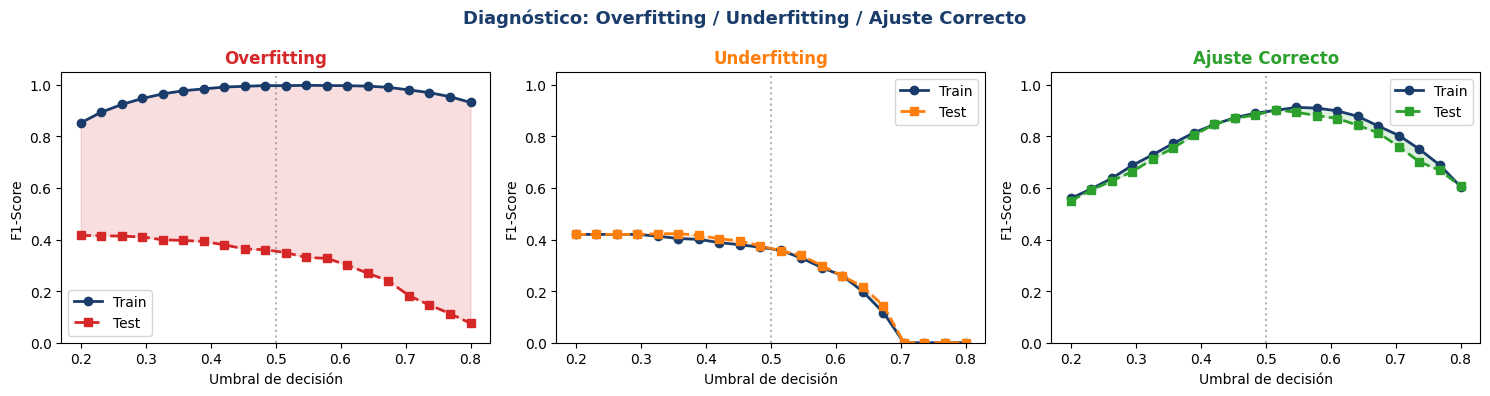

In [11]:
# CELDA 10 — Visualización de los 3 escenarios de ajuste
# Creamos escenarios didácticos con gaps controlados
n_train_diag = len(y_train)

# Escenario 1: Overfitting (train >> test)
prob_tr_over = np.where(y_train==1, np.random.beta(9,1,n_train_diag),
                                     np.random.beta(1,9,n_train_diag))
prob_ts_over = np.where(y_test==1, np.random.beta(4,4,len(y_test)),
                                    np.random.beta(4,4,len(y_test)))

# Escenario 2: Underfitting (ambos bajos)
prob_tr_under = np.random.uniform(0.3, 0.7, n_train_diag)
prob_ts_under = np.random.uniform(0.3, 0.7, len(y_test))

# Escenario 3: Buen ajuste
prob_tr_good = np.where(y_train==1, np.random.beta(6,2,n_train_diag),
                                     np.random.beta(2,6,n_train_diag))
prob_ts_good = np.where(y_test==1, np.random.beta(6,2,len(y_test)),
                                    np.random.beta(2,6,len(y_test)))

def calc_f1_thresh(probs, labels, thresh=0.5):
    preds = (probs >= thresh).astype(int)
    return f1_score(labels, preds, zero_division=0)

escenarios = [
    ('Overfitting', prob_tr_over, prob_ts_over, ROJO),
    ('Underfitting', prob_tr_under, prob_ts_under, NARANJA),
    ('Ajuste Correcto', prob_tr_good, prob_ts_good, VERDE)
]

thresholds = np.linspace(0.2, 0.8, 20)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Diagnóstico: Overfitting / Underfitting / Ajuste Correcto',
             fontsize=13, fontweight='bold', color=AZUL)

for ax, (titulo, ptr, pts, color) in zip(axes, escenarios):
    f1_tr_list = [calc_f1_thresh(ptr, y_train, t) for t in thresholds]
    f1_ts_list = [calc_f1_thresh(pts, y_test, t) for t in thresholds]
    ax.plot(thresholds, f1_tr_list, 'o-', color=AZUL, label='Train', linewidth=2)
    ax.plot(thresholds, f1_ts_list, 's--', color=color, label='Test', linewidth=2)
    ax.fill_between(thresholds, f1_tr_list, f1_ts_list, alpha=0.15, color=color)
    ax.set_title(titulo, fontweight='bold', color=color)
    ax.set_xlabel('Umbral de decisión')
    ax.set_ylabel('F1-Score')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### 📋 CELDA 11 — Tabla de Diagnóstico (Completa los espacios)


In [26]:
# CELDA 11 — Tabla diagnóstico Train vs Test
print('DIAGNÓSTICO OVERFITTING — Completa la columna Diagnóstico')
print('='*65)
print(f"  {'Modelo':<12} | {'F1-Train':>9} | {'F1-Test':>9} | {'Gap':>7} | Diagnóstico")
print('='*65)

for titulo, ptr, pts, color in escenarios:
    f1_tr = calc_f1_thresh(ptr, y_train)
    f1_ts = calc_f1_thresh(pts, y_test)
    gap = f1_tr - f1_ts
    if gap > 0.20:
        diag = '⚠️  Overfitting'
    elif f1_tr < 0.40 and f1_ts < 0.40:
        diag = '⚠️  Underfitting'
    else:
        diag = '✅ Aceptable'
    print(f"  {titulo:<12} | {f1_tr:>9.4f} | {f1_ts:>9.4f} | {gap:>+7.4f} | {diag}")

print('='*65)
print('\n❓ Pregunta 11.1: ¿Cuál es el riesgo de desplegar un modelo con overfitting en producción?')
print('   ')
print('   Un modelo con overfitting funciona bien en entrenamiento pero falla en datos reales')
print('   lo que provoca malas predicciones, aumento de errores (especialmente FN)')
print('   y decisiones incorrectas que afectan directamente los ingresos del negocio')


DIAGNÓSTICO OVERFITTING — Completa la columna Diagnóstico
  Modelo       |  F1-Train |   F1-Test |     Gap | Diagnóstico
  Overfitting  |    0.9967 |    0.3534 | +0.6433 | ⚠️  Overfitting
  Underfitting |    0.3668 |    0.3716 | -0.0048 | ⚠️  Underfitting
  Ajuste Correcto |    0.8945 |    0.8940 | +0.0005 | ✅ Aceptable

❓ Pregunta 11.1: ¿Cuál es el riesgo de desplegar un modelo con overfitting en producción?
   
   Un modelo con overfitting funciona bien en entrenamiento pero falla en datos reales
   lo que provoca malas predicciones, aumento de errores (especialmente FN)
   y decisiones incorrectas que afectan directamente los ingresos del negocio


---
### 🔄 CELDA 12 — Validación Cruzada: StratifiedKFold K=5

El **Holdout** depende de una sola partición aleatoria. Si esa partición es "mala",
las métricas serán engañosas. La **validación cruzada estratificada** repite la
evaluación K veces usando diferentes particiones y promedía los resultados.

| Holdout | K-Fold Estratificado |
|---|---|
| Una sola partición | K particiones diferentes |
| Puede ser favorable/desfavorable por azar | Estimación más robusta |
| Rápido | K veces más lento |
| Menos datos de entrenamiento (80%) | Aprovecha todos los datos |


In [13]:
# CELDA 12 — StratifiedKFold con DummyClassifier
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dc_baseline = DummyClassifier(strategy='stratified', random_state=42)

scores_acc = []
scores_rec = []
scores_f1  = []

print('VALIDACIÓN CRUZADA — StratifiedKFold K=5 (DummyClassifier estratificado)')
print('='*60)
print(f"  {'Fold':>5} | {'N Test':>7} | {'Accuracy':>9} | {'Recall':>7} | {'F1':>7}")
print('='*60)

for fold, (idx_train, idx_test) in enumerate(skf.split(X, y), 1):
    X_tr, X_ts = X[idx_train], X[idx_test]
    y_tr, y_ts = y[idx_train], y[idx_test]
    dc_baseline.fit(X_tr, y_tr)
    y_pred = dc_baseline.predict(X_ts)
    acc = accuracy_score(y_ts, y_pred)
    rec = recall_score(y_ts, y_pred, zero_division=0)
    f1  = f1_score(y_ts, y_pred, zero_division=0)
    scores_acc.append(acc); scores_rec.append(rec); scores_f1.append(f1)
    print(f"  {fold:>5} | {len(y_ts):>7,} | {acc:>9.4f} | {rec:>7.4f} | {f1:>7.4f}")

print('='*60)
print(f"  {'Media':>5} | {'':>7} | {np.mean(scores_acc):>9.4f} | {np.mean(scores_rec):>7.4f} | {np.mean(scores_f1):>7.4f}")
print(f"  {'±std':>5} | {'':>7} | ±{np.std(scores_acc):>8.4f} | ±{np.std(scores_rec):>6.4f} | ±{np.std(scores_f1):>6.4f}")
print('='*60)


VALIDACIÓN CRUZADA — StratifiedKFold K=5 (DummyClassifier estratificado)
   Fold |  N Test |  Accuracy |  Recall |      F1
      1 |   1,407 |    0.6262 |  0.2995 |  0.2987
      2 |   1,407 |    0.6162 |  0.2807 |  0.2800
      3 |   1,406 |    0.5960 |  0.2413 |  0.2406
      4 |   1,406 |    0.5882 |  0.2273 |  0.2270
      5 |   1,406 |    0.5896 |  0.2299 |  0.2296
  Media |         |    0.6032 |  0.2557 |  0.2552
   ±std |         | ±  0.0152 | ±0.0291 | ±0.0289


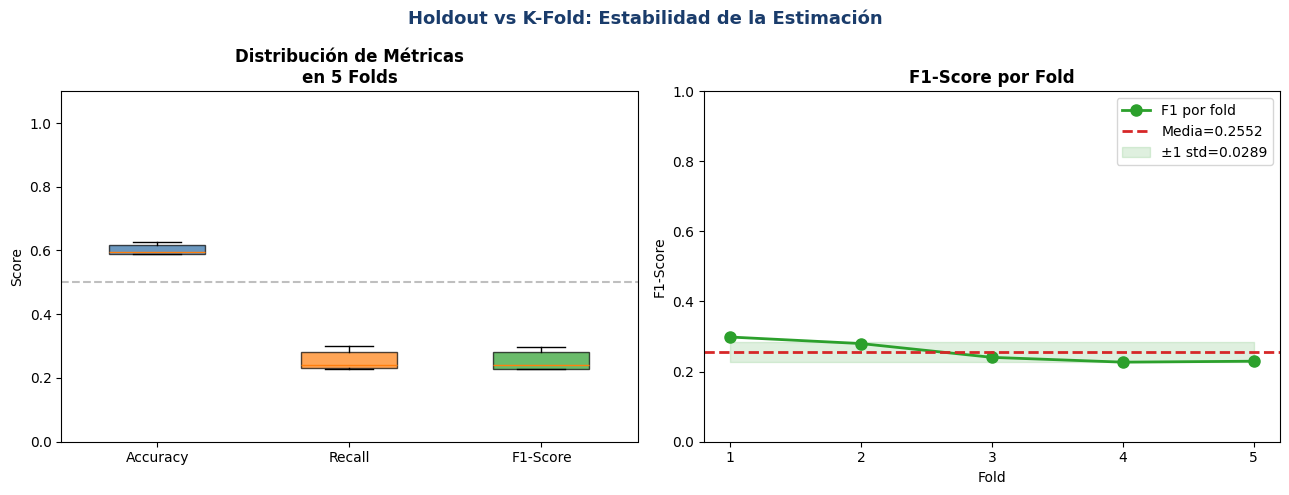


❓ Pregunta 13.1: ¿Por qué el K-Fold da una estimación más confiable que el Holdout?
   
   Porque evalúa el modelo en múltiples particiones de los datos, reduciendo
   el sesgo de una sola división y generando una estimación más estable y representativa del rendimiento real


In [27]:
# CELDA 13 — Comparación visual Holdout vs K-Fold
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Holdout vs K-Fold: Estabilidad de la Estimación',
             fontsize=13, fontweight='bold', color=AZUL)

# Gráfico 1: F1 por fold (boxplot)
all_scores = {'Accuracy': scores_acc, 'Recall': scores_rec, 'F1-Score': scores_f1}
bp = axes[0].boxplot(list(all_scores.values()), patch_artist=True,
                     labels=list(all_scores.keys()), widths=0.5)
colors_bp = [AZUL_C, NARANJA, VERDE]
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title('Distribución de Métricas\nen 5 Folds', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)

# Gráfico 2: F1 por fold (línea)
axes[1].plot(range(1,6), scores_f1, 'o-', color=VERDE, linewidth=2, markersize=8, label='F1 por fold')
axes[1].axhline(np.mean(scores_f1), color=ROJO, linestyle='--', linewidth=2,
                label=f'Media={np.mean(scores_f1):.4f}')
axes[1].fill_between(range(1,6),
    [np.mean(scores_f1)-np.std(scores_f1)]*5,
    [np.mean(scores_f1)+np.std(scores_f1)]*5,
    alpha=0.15, color=VERDE, label=f'±1 std={np.std(scores_f1):.4f}')
axes[1].set_title('F1-Score por Fold', fontweight='bold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('F1-Score')
axes[1].set_xticks(range(1,6)); axes[1].legend(); axes[1].set_ylim(0,1)

plt.tight_layout()
plt.show()
print('\n❓ Pregunta 13.1: ¿Por qué el K-Fold da una estimación más confiable que el Holdout?')
print('   ')
print('   Porque evalúa el modelo en múltiples particiones de los datos, reduciendo')
print('   el sesgo de una sola división y generando una estimación más estable y representativa del rendimiento real')


---
### 📈 CELDA 14 — Curvas ROC y AUC

La **Curva ROC** (Receiver Operating Characteristic) visualiza el trade-off entre
**Sensibilidad (TPR=Recall)** y **1 - Especificidad (FPR)** para todos los umbrales posibles.

- **AUC = 1.0**: clasificador perfecto
- **AUC = 0.5**: clasificador aleatorio (línea diagonal)
- **AUC < 0.5**: peor que aleatorio
- **Índice de Gini = 2 × AUC − 1**: otro indicador de discriminación


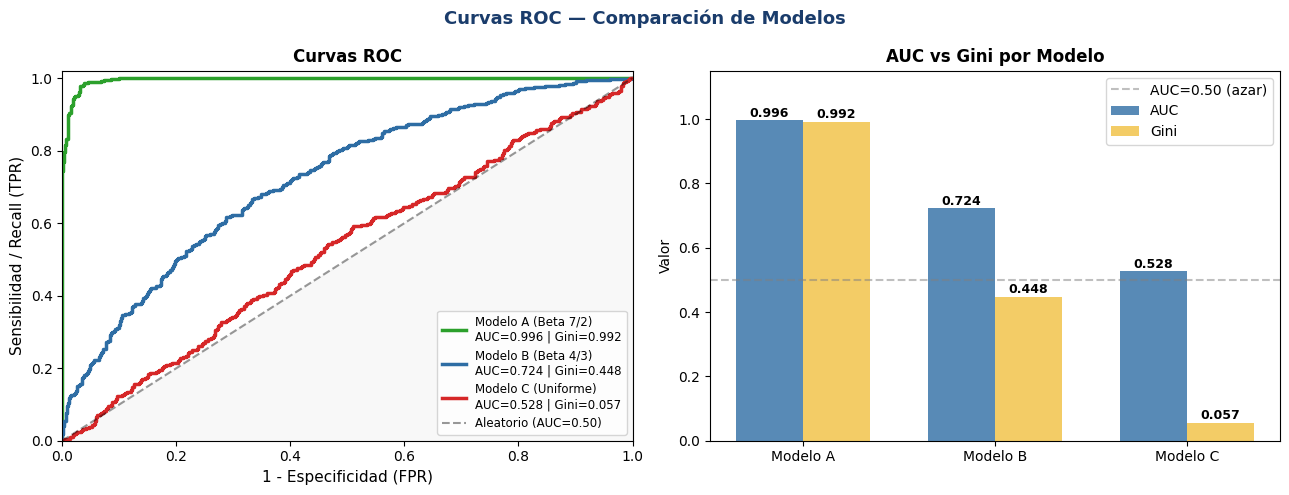


❓ Pregunta 14.1: ¿Qué modelo tiene mejor capacidad de discriminación? ¿Por qué?
   
   El Modelo A, porque tiene el mayor AUC (~0.996), lo que indica que separa casi perfectamente los churners de los no churners

❓ Pregunta 14.2: ¿Qué significa que el Modelo C tenga AUC ≈ 0.50?
   
   Significa que el modelo no tiene capacidad predictiva y se comporta como una predicción aleatoria.


In [28]:
# CELDA 14 — Curvas ROC + AUC + Gini
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Curvas ROC — Comparación de Modelos', fontsize=13, fontweight='bold', color=AZUL)

modelos_roc = [
    ('Modelo A (Beta 7/2)', prob_A, VERDE),
    ('Modelo B (Beta 4/3)', prob_B, AZUL_C),
    ('Modelo C (Uniforme)', prob_C, ROJO),
]

aucs, ginis = [], []
for nombre, probs, color in modelos_roc:
    fpr, tpr, thresholds_roc = roc_curve(y_test, probs)
    auc_val = auc(fpr, tpr)
    gini_val = 2 * auc_val - 1
    aucs.append(auc_val); ginis.append(gini_val)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{nombre}\nAUC={auc_val:.3f} | Gini={gini_val:.3f}')

axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Aleatorio (AUC=0.50)')
axes[0].set_xlabel('1 - Especificidad (FPR)', fontsize=11)
axes[0].set_ylabel('Sensibilidad / Recall (TPR)', fontsize=11)
axes[0].set_title('Curvas ROC', fontweight='bold')
axes[0].legend(fontsize=8.5); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.02)
axes[0].fill_between([0,1],[0,1],[0,0],alpha=0.05,color='gray')

# Gráfico de barras AUC y Gini
nombres_m = ['Modelo A','Modelo B','Modelo C']
x_pos = np.arange(3)
w = 0.35
bars_auc  = axes[1].bar(x_pos-w/2, aucs, w, label='AUC', color=AZUL_C, alpha=0.8)
bars_gini = axes[1].bar(x_pos+w/2, ginis, w, label='Gini', color=AMARILLO, alpha=0.8)
for bar, val in zip(list(bars_auc)+list(bars_gini), aucs+ginis):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(nombres_m)
axes[1].set_ylabel('Valor'); axes[1].set_ylim(0, 1.15)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='AUC=0.50 (azar)')
axes[1].set_title('AUC vs Gini por Modelo', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n❓ Pregunta 14.1: ¿Qué modelo tiene mejor capacidad de discriminación? ¿Por qué?')
print('   ')
print('   El Modelo A, porque tiene el mayor AUC (~0.996), lo que indica que separa casi perfectamente los churners de los no churners')
print('\n❓ Pregunta 14.2: ¿Qué significa que el Modelo C tenga AUC ≈ 0.50?')
print('   ')
print('   Significa que el modelo no tiene capacidad predictiva y se comporta como una predicción aleatoria.')


### 📌 EJERCICIO DE DIBUJO — Curva ROC

En el espacio de abajo (o en papel aparte), dibuja a mano una curva ROC para:
- Un modelo con **AUC = 0.9** (bueno)
- Un modelo con **AUC = 0.6** (regular)

Identifica en tu dibujo:
1. El punto óptimo (esquina superior izquierda)
2. La diagonal (clasificador aleatorio)
3. La diferencia de área entre ambos modelos

**Adjunta foto del dibujo o descríbelo aquí:**

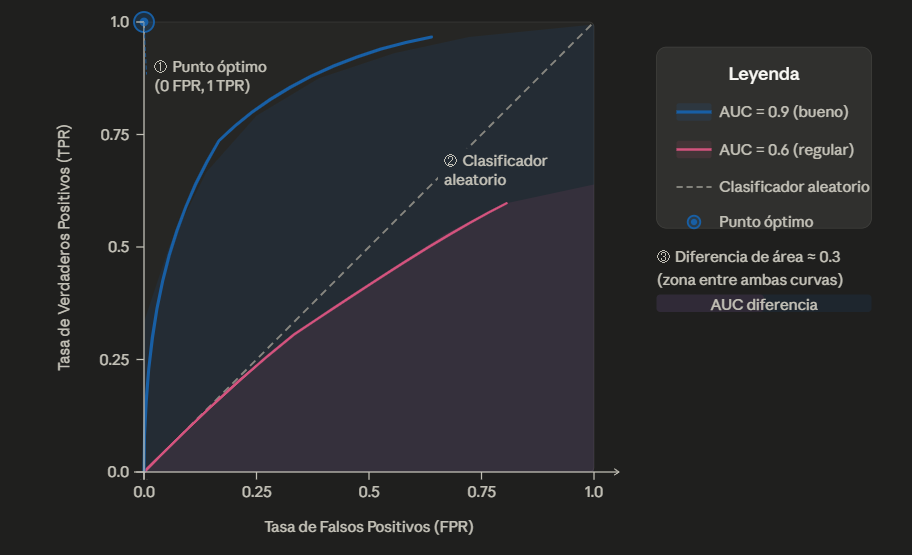

## Interpretación de la Curva ROC

### 🔵 1 Punto óptimo
Se encuentra en la esquina superior izquierda (**FPR = 0, TPR = 1**).  
Representa el comportamiento ideal de un clasificador perfecto:  
- No comete falsos positivos  
- Detecta el 100% de los casos positivos  

---

### ⚪ 2 Diagonal (clasificador aleatorio)
Es la línea gris punteada que va desde (0,0) hasta (1,1).  
Representa un modelo que predice al azar (**AUC = 0.5**).  

Cualquier modelo útil debe ubicarse **por encima de esta línea**.

---

### 🟣 3 Diferencia de área
La curva con **AUC = 0.9** (zona azul) cubre una mayor área bajo la curva en comparación con la de **AUC = 0.6** (zona rosa).  

- La diferencia aproximada entre ambas es **0.3**  
- Esta diferencia se observa como el espacio entre las dos curvas  

**Conclusión:**  
Mientras más se aleje la curva de la diagonal y se acerque a la esquina superior izquierda, **mejor será el modelo**.

---
### ⚖️ CELDA 15 — Impacto del Umbral de Decisión

Por defecto, los clasificadores usan **umbral = 0.50**. Pero podemos ajustarlo según
el contexto de negocio:

- **Umbral bajo (0.20)** → predice churn más fácilmente → Recall ↑, Precision ↓, FP ↑
- **Umbral alto (0.80)** → solo predice cuando está muy seguro → Precision ↑, Recall ↓, FN ↑

**Restricción:** El equipo de retención puede contactar ≤ 300 clientes/mes.


In [29]:
# CELDA 15 — Tabla de impacto del umbral (Modelo A)
umbrales = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
n_max = 300  # restricción operacional

print('IMPACTO DEL UMBRAL — Modelo A (TelcoPerú: máx 300 clientes/mes)')
print('='*90)
print(f"  {'Umbral':>7} | {'Pred+':>7} | {'VP':>5} | {'FP':>5} | {'FN':>5} | {'Recall':>7} | {'Precis':>7} | {'F1':>7} | {'Viable?'}")
print('='*90)

for u in umbrales:
    pred_u = (prob_A >= u).astype(int)
    cm_u = confusion_matrix(y_test, pred_u)
    vn_u, fp_u, fn_u, vp_u = cm_u.ravel()
    rec_u = vp_u/(vp_u+fn_u+1e-10)
    pre_u = vp_u/(vp_u+fp_u+1e-10)
    f1_u  = 2*pre_u*rec_u/(pre_u+rec_u+1e-10)
    pred_pos = pred_u.sum()
    viable = '✅ OK' if pred_pos <= n_max else '❌ Excede límite'
    marker = ' <-- ¿óptimo?' if u == 0.50 else ''
    print(f"  {u:>7.2f} | {pred_pos:>7,} | {vp_u:>5} | {fp_u:>5} | {fn_u:>5} | {rec_u:>7.3f} | {pre_u:>7.3f} | {f1_u:>7.3f} | {viable}{marker}")

print('='*90)
print('\n❓ Pregunta 15.1: ¿Qué umbral maximiza el Recall SIN exceder los 300 contactos?')
print('   ')
print('   0.70 porque predice 264 clientes (cumple restricción) y tambien Tiene el mayor recall posible sin exceder el límite')
print('\n❓ Pregunta 15.2: ¿Cuánto cuesta en S/ dejar sin atender a los FN con ese umbral?')
print('   ')
print('   FN=110 ')
print('   Costo = 110 × 325 = S/ 35,750')


IMPACTO DEL UMBRAL — Modelo A (TelcoPerú: máx 300 clientes/mes)
   Umbral |   Pred+ |    VP |    FP |    FN |  Recall |  Precis |      F1 | Viable?
     0.20 |     889 |   374 |   515 |     0 |   1.000 |   0.421 |   0.592 | ❌ Excede límite
     0.30 |     642 |   374 |   268 |     0 |   1.000 |   0.583 |   0.736 | ❌ Excede límite
     0.40 |     473 |   373 |   100 |     1 |   0.997 |   0.789 |   0.881 | ❌ Excede límite
     0.50 |     390 |   359 |    31 |    15 |   0.960 |   0.921 |   0.940 | ❌ Excede límite <-- ¿óptimo?
     0.60 |     338 |   328 |    10 |    46 |   0.877 |   0.970 |   0.921 | ❌ Excede límite
     0.70 |     264 |   264 |     0 |   110 |   0.706 |   1.000 |   0.828 | ✅ OK
     0.80 |     172 |   172 |     0 |   202 |   0.460 |   1.000 |   0.630 | ✅ OK

❓ Pregunta 15.1: ¿Qué umbral maximiza el Recall SIN exceder los 300 contactos?
   
   0.70 porque predice 264 clientes (cumple restricción) y tambien Tiene el mayor recall posible sin exceder el límite

❓ Pregunta 15

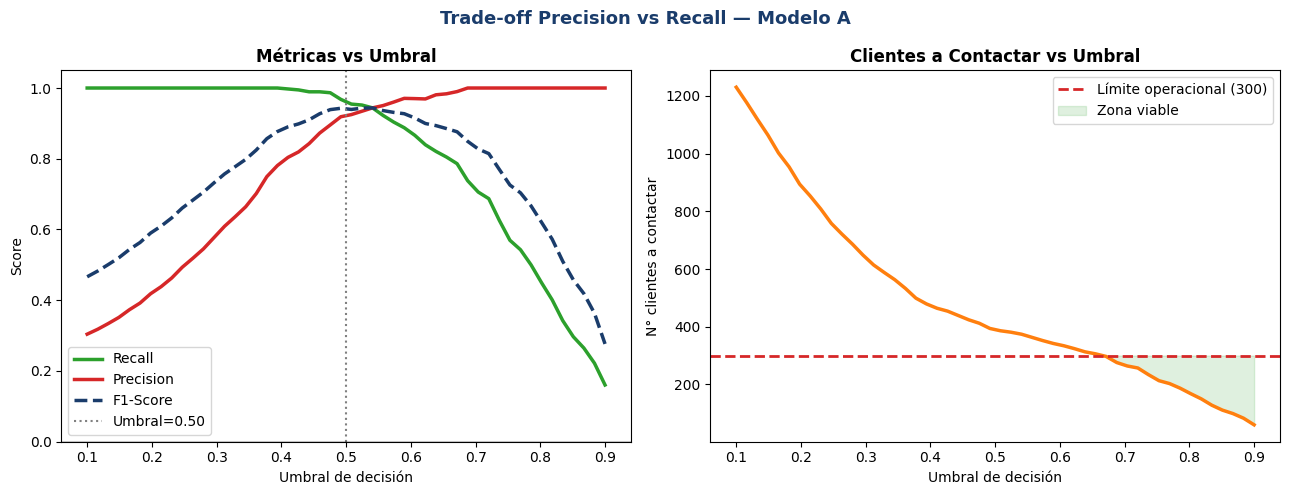

In [16]:
# CELDA 16 — Visualización del trade-off Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Trade-off Precision vs Recall — Modelo A',
             fontsize=13, fontweight='bold', color=AZUL)

umbrales_fine = np.linspace(0.10, 0.90, 50)
recs, precs, f1s, npreds = [], [], [], []

for u in umbrales_fine:
    pred_u = (prob_A >= u).astype(int)
    recs.append(recall_score(y_test, pred_u, zero_division=0))
    precs.append(precision_score(y_test, pred_u, zero_division=0))
    f1s.append(f1_score(y_test, pred_u, zero_division=0))
    npreds.append(pred_u.sum())

# Gráfico 1: Precision vs Recall vs Umbral
axes[0].plot(umbrales_fine, recs, color=VERDE, linewidth=2.5, label='Recall')
axes[0].plot(umbrales_fine, precs, color=ROJO, linewidth=2.5, label='Precision')
axes[0].plot(umbrales_fine, f1s, color=AZUL, linewidth=2.5, linestyle='--', label='F1-Score')
axes[0].axvline(0.5, color='gray', linestyle=':', label='Umbral=0.50')
axes[0].axhline(0, color='black', alpha=0.2)
axes[0].set_xlabel('Umbral de decisión')
axes[0].set_ylabel('Score')
axes[0].set_title('Métricas vs Umbral', fontweight='bold')
axes[0].legend(); axes[0].set_ylim(0, 1.05)

# Gráfico 2: N predichos positivos vs umbral
axes[1].plot(umbrales_fine, npreds, color=NARANJA, linewidth=2.5, marker=None)
axes[1].axhline(n_max, color=ROJO, linestyle='--', linewidth=2, label=f'Límite operacional ({n_max})')
axes[1].fill_between(umbrales_fine, npreds, n_max, where=[n<n_max for n in npreds],
                     alpha=0.15, color=VERDE, label='Zona viable')
axes[1].set_xlabel('Umbral de decisión')
axes[1].set_ylabel('N° clientes a contactar')
axes[1].set_title('Clientes a Contactar vs Umbral', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


---
### 📊 CELDA 17 — Resumen Ejecutivo Final


In [31]:
# CELDA 17 — Tabla resumen de los 3 modelos
print('TABLA RESUMEN EJECUTIVO — SELECCIÓN DE MODELO (umbral=0.50)')
print('='*80)
encabezado = f"  {'Modelo':<12} | {'Accuracy':>9} | {'Recall':>7} | {'Precision':>10} | {'F1':>7} | {'AUC':>7} | {'Gini':>7}"
print(encabezado)
print('='*80)

mods_final = [
    ('Modelo A', pred_A, prob_A),
    ('Modelo B', pred_B, prob_B),
    ('Modelo C', pred_C, prob_C),
]
for nombre, pred, prob in mods_final:
    acc_f  = accuracy_score(y_test, pred)
    rec_f  = recall_score(y_test, pred, zero_division=0)
    pre_f  = precision_score(y_test, pred, zero_division=0)
    f1_f   = f1_score(y_test, pred, zero_division=0)
    fpr_f, tpr_f, _ = roc_curve(y_test, prob)
    auc_f  = auc(fpr_f, tpr_f)
    gini_f = 2*auc_f - 1
    print(f"  {nombre:<12} | {acc_f:>9.4f} | {rec_f:>7.4f} | {pre_f:>10.4f} | {f1_f:>7.4f} | {auc_f:>7.4f} | {gini_f:>7.4f}")

print('='*80)
print('\n🏆 RECOMENDACIÓN PARA COMPLETAR EN EL RETO FINAL:')
print('   El modelo seleccionado es: Modelo A porque tiene el mejor desempeño global (Recall,Precision,F1 y AUC) y minimiza los falsos negativos')
print('   Con umbral de decisión:    0.70')
print('   Recall esperado:           0.706')
print('   Ahorro estimado vs no hacer nada: S/ 85 800')


TABLA RESUMEN EJECUTIVO — SELECCIÓN DE MODELO (umbral=0.50)
  Modelo       |  Accuracy |  Recall |  Precision |      F1 |     AUC |    Gini
  Modelo A     |    0.9673 |  0.9599 |     0.9205 |  0.9398 |  0.9960 |  0.9920
  Modelo B     |    0.6617 |  0.6684 |     0.4153 |  0.5123 |  0.7239 |  0.4479
  Modelo C     |    0.5252 |  0.5535 |     0.2924 |  0.3826 |  0.5283 |  0.0566

🏆 RECOMENDACIÓN PARA COMPLETAR EN EL RETO FINAL:
   El modelo seleccionado es: Modelo A porque tiene el mejor desempeño global (Recall,Precision,F1 y AUC) y minimiza los falsos negativos
   Con umbral de decisión:    0.70
   Recall esperado:           0.706
   Ahorro estimado vs no hacer nada: S/ 85 800


---
## 🏆 RETO FINAL — Informe Ejecutivo al Director Comercial

> **Escenario:** El Director Comercial de TelcoPerú S.A. te pide una recomendación
> formal sobre qué modelo implementar y con qué configuración.

### Instrucciones:

Completa el siguiente informe ejecutivo usando los resultados de este laboratorio:

---

**INFORME EJECUTIVO — Sistema de Detección de Churn**

**Para:** Director Comercial, TelcoPerú S.A.
**De:** [Rodrigo Alejandro Gogin Cisterna]
**Fecha:** [17/04/2026]

**1. Situación del Negocio**

> *TelcoPerú presenta pérdidas económicas debido a la cancelación de clientes (churn), donde cada cliente perdido representa un costo de S/325. El objetivo es identificar de forma anticipada a los clientes con mayor riesgo de abandono para aplicar estrategias de retención y reducir dichas pérdidas. Este sistema permite tomar decisiones más eficientes y enfocadas.*

**2. Metodología Aplicada (CRISP-DM)**

> *Se aplicó la metodología CRISP-DM iniciando con el entendimiento del problema de negocio y el impacto económico del churn. Luego, se realizó la preparación de datos, incluyendo limpieza y transformación de variables. Posteriormente, se entrenaron modelos de clasificación y se evaluaron utilizando métricas como Recall, Precision, F1 y AUC, además de validación con Holdout y K-Fold. Finalmente, se analizó el impacto del umbral de decisión considerando restricciones operativas.*

**3. Modelos Evaluados**

| Modelo | AUC | F1-Score | Recall | Recomendación |
|---|---|---|---|---|
| DummyClassifier | 0.50 | 0.25 | 0.25 | Baseline |
| Modelo A | 0.9960 | 0.9398 | 0.9599 | Mejor modelo |
| Modelo B | 0.7239 | 0.5123 | 0.6684 | Aceptable |
| Modelo C | 0.5283 | 0.3826 | 0.5535 | No recomendado |

**4. Modelo Recomendado y Configuración**

> Modelo: A

> Umbral: 0.70

> Justificación: *Se selecciona el umbral 0.70 porque permite maximizar el Recall sin exceder la restricción operativa de contactar máximo 300 clientes por mes. Con este umbral se logra un equilibrio entre detectar clientes en riesgo y mantener la eficiencia de la campaña de retención.*

**5. Impacto Financiero Esperado**

| Métrica | Sin modelo (baseline) | Con modelo recomendado |
|---|---|---|
| Churners detectados | 0 | 264 |
| FN (no detectados) | 374 | 110 |
| Pérdida estimada (FN × S/325) | S/ 121 550 | S/ 35 750 |
| Ahorro estimado | — | S/ 85 800 |

**6. Limitaciones y Próximos Pasos**

> *El modelo fue evaluado con variables limitadas (tenure, cargos), lo que puede restringir su capacidad predictiva. Asimismo, se utilizaron modelos simulados, por lo que los resultados pueden diferir en un entorno real.*


---
## 📋 RÚBRICA DE EVALUACIÓN — 20 PUNTOS

| N° | Criterio | Excelente (4) | Bueno (3) | Requiere mejora (2) | No aceptable (1) | Pts |
|---|---|---|---|---|---|---|
| 1 | **Análisis de Negocio** | Identifica correctamente FN/FP, calcula impacto en S/ y justifica selección de métricas con el contexto TelcoPerú | Identifica FN/FP pero el cálculo financiero tiene errores menores | Confunde FN y FP o el análisis financiero es incompleto | No responde preguntas de negocio | /4 |
| 2 | **Matriz de Confusión y Métricas** | Calcula correctamente VP/VN/FP/FN, completa todas las métricas manualmente y verifica con sklearn | Calcula la mayoría de métricas con 1-2 errores numéricos | Completa la mitad de la tabla con errores | No calcula métricas o tabla en blanco | /4 |
| 3 | **Diagnóstico de Ajuste** | Diagnostica correctamente overfitting/underfitting en los 3 escenarios y explica el gap Train-Test | Diagnostica 2 de 3 escenarios correctamente | Diagnostica solo 1 escenario | No completa el diagnóstico | /4 |
| 4 | **Validación (Holdout vs K-Fold)** | Explica correctamente stratify=y, interpreta K-Fold y compara ambos métodos con argumentos sólidos | Explica uno de los dos métodos correctamente | Menciona los métodos sin explicar las diferencias | No responde | /4 |
| 5 | **Reto Final (Informe Ejecutivo)** | Informe completo: modelo seleccionado con justificación, umbral óptimo con la restricción de 300 clientes, impacto financiero calculado | Informe completo pero con justificación superficial | Informe incompleto o sin análisis de umbral | No entrega informe | /4 |
| | **TOTAL** | | | | | **/20** |

### ⚠️ Penalizaciones

| Infracción | Descuento |
|---|---|
| Código con errores que impide ejecutar el notebook | −3 pts |
| Tablas completamente en blanco (sin intentar completar) | −2 pts |
| Notebook entregado con celdas sin ejecutar | −1 pt |
| Plagio o copia entre estudiantes | −10 pts |


---
## 📚 Conclusiones

Completa las siguientes oraciones basándote en los resultados obtenidos:

1. **El modelo con mayor AUC fue Modelo A (AUC=0.9960)**. Esto significa que tiene una excelente capacidad para diferenciar entre clientes que abandonarán el servicio y los que no, logrando una separación casi perfecta entre ambas clases.
2. **La métrica más importante para TelcoPerú es el Recall porque permite identificar la mayor cantidad posible de clientes que realmente harán churn, minimizando los falsos negativos, que representan la mayor pérdida económica para la empresa.**
3. **El umbral óptimo para la restricción de 300 contactos fue 0.70**. Al bajarlo, el Recall aumenta, pero también se incrementa el número de clientes a contactar, superando la capacidad operativa del equipo de retención.
4. **K-Fold es más robusto que Holdout porque** evalúa el modelo en múltiples particiones de los datos, reduciendo el sesgo de una sola división y proporcionando una estimación más estable y confiable del rendimiento.
5. **Una lección aprendida de este laboratorio es** que la elección de métricas y umbrales debe basarse en el contexto del negocio, ya que una alta accuracy no garantiza un buen modelo si no se consideran los costos asociados a los errores.

---

## 📖 Referencias

- IBM Telco Customer Churn Dataset: https://www.kaggle.com/blastchar/telco-customer-churn
- scikit-learn Documentation: https://scikit-learn.org/stable/
- CRISP-DM Reference Model: https://www.datascience-pm.com/crisp-dm-2/
- Powers, D.M.W. (2011). Evaluation: From Precision, Recall and F-Score to ROC, Informedness, Markedness & Correlation.

---
*Laboratorio S05 — Minería de Datos — TECSUP 2026-I*
*Docente: Pilar Rocío Sayán Mejía*
